# **EXERCISE 2 - Convolutional Neural Networks**

**Group 2607**
* Daniele Ghezzi 2195461 (daniele.ghezzi@studenti.unipd.it)
* Fabio Cimino 2197528 (fabio.cimino@studenti.unipd.it)
* Riccardo Ferrante 2196576 (riccardo.ferrante@studenti.unipd.it)
* Federico Scianna 2183435 (federico.scianna@studenti.unipd.it)

## **0. Preliminary work**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D, GlobalMaxPool1D
import tensorflow.random as tf_r
import seaborn as sns

In [3]:
def Show_data(x,L,s="data"):
    plt.plot(np.arange(L),x[0])
    plt.plot(np.arange(L,2*L),x[1])
    plt.plot(np.arange(2*L,3*L),x[2])
    plt.title(s)
    plt.xlabel("time")
    plt.show()

### Data Generation

In [4]:
## random seed for reproducibility
np.random.seed(12345)
# pattern parameters: Z=nr of steps, A=amplitude
Z=12
# number of data samples
N=10000
# size of each sample of the timeseries
L=60
# step parameters: introduce small positive bias
DX = 50 # standard deviation of the random step
bias = 5  # bias to make the random walk drift in the positive direction
# different values for the amplitude
amplitudes = np.arange(50, 1001, 50)
# jump
jump = lambda drift, stdev: int(np.random.normal(drift,stdev))
# other useful variables
n_class = 3
input_shape = (L,1)
# pattern
def pattern(i,z,a):
    return int(a*np.sin((np.pi*i)/z))

In [5]:
def generate_data(A):
    y = [0] * N # initialize class labels with zeros
    x = [[0] * L for i in range(N)] # initialize timeseries with zeros

    for i in range(N):
        if i>0:
            x[i][0] = x[i-1][-1] + jump(bias,DX) # first step of the new sample starts from the last point of the previous one
        
        for j in range(1,L):
            x[i][j] = x[i][j-1] + jump(bias,DX) # random walk with bias
            
        y[i] = i%3 # assign class labels (0,1,2)
        ##y[i] = random.randint(0,2) # random assingment
        if y[i]>0:
            j0 = np.random.randint(0,L-1-Z) # random starting point for the pattern
            ###print(i,j0,j1)
            sign = 3-2*y[i] # sign of the pattern: + for class 1, - for class 2
            for j in range(Z):
                x[i][j0+j] += sign*pattern(j,Z,A) # add pattern to the timeseries
                
    #for i in range(min(3,N)):
    #    print(x[i],y[i])

    !mkdir DATA
    str0 = f'ts_L{L}_Z{Z}_A{A}_DX{DX}_bias{bias}_N{N}.dat'
    print(str0)

    fname='DATA/x_'+str0
    np.savetxt(fname,x,fmt="%d")
    fname='DATA/y_'+str0
    np.savetxt(fname,y,fmt="%d")

In [6]:
for A in amplitudes:
    generate_data(A)

mkdir: cannot create directory ‘DATA’: File exists
ts_L60_Z12_A50_DX50_bias5_N10000.dat
mkdir: cannot create directory ‘DATA’: File exists
ts_L60_Z12_A100_DX50_bias5_N10000.dat
mkdir: cannot create directory ‘DATA’: File exists
ts_L60_Z12_A150_DX50_bias5_N10000.dat
mkdir: cannot create directory ‘DATA’: File exists
ts_L60_Z12_A200_DX50_bias5_N10000.dat
mkdir: cannot create directory ‘DATA’: File exists
ts_L60_Z12_A250_DX50_bias5_N10000.dat
mkdir: cannot create directory ‘DATA’: File exists
ts_L60_Z12_A300_DX50_bias5_N10000.dat
mkdir: cannot create directory ‘DATA’: File exists
ts_L60_Z12_A350_DX50_bias5_N10000.dat
mkdir: cannot create directory ‘DATA’: File exists
ts_L60_Z12_A400_DX50_bias5_N10000.dat
mkdir: cannot create directory ‘DATA’: File exists
ts_L60_Z12_A450_DX50_bias5_N10000.dat
mkdir: cannot create directory ‘DATA’: File exists
ts_L60_Z12_A500_DX50_bias5_N10000.dat
mkdir: cannot create directory ‘DATA’: File exists
ts_L60_Z12_A550_DX50_bias5_N10000.dat
mkdir: cannot create d

### Read data

In [7]:
def read_data(A):
    str0 = f"ts_L60_Z12_A{A}_DX50_bias5_N10000.dat"
    fnamex='DATA/x_'+str0 # file containing time series
    fnamey='DATA/y_'+str0 # file containing labels

    x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
    # number of samples, number of features
    N,L = len(x), len(x[0])

    #Show_data(x,L,f"original data, amplitude = {A}")

    categ = np.loadtxt(fnamey, dtype=int)
    #print('data: ',N)

    y = np.zeros((N,n_class)) # create a 10'000 * 3 matrix, whose rows will containing the classes(0: [1, 0, 0], 1: [0, 1, 0], 2:[0, 0, 1])
    for i in range(N):
        y[i][categ[i]] = 1. # y contains one-hot encoding
    return x, y;
    
"""
for A in amplitudes:
    read_data(A)
"""

'\nfor A in amplitudes:\n    read_data(A)\n'

### Split train-validation and rescale

In [8]:
def split_train_validation_rescale(x, y):
    # split into training and validation sets
    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    #print(x_train.shape)
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    #print('N_train=',N_train,'  N_val=',N_val,'  L=',L,'  n_class=',n_class)

    
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    #print('std_train average and mean:',max(std_train), min(std_train), std_train.mean(axis=0))
    #print('std_val average and mean:',max(std_val), min(std_val), std_val.mean(axis=0))

    # rescale with variance on the training set
    for i in range(N_train):
        x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)

        
    #Show_data(x_train,L,"rescaled train data")
    #Show_data(x_val,L,"rescaled validation data")

    # Keras wants an additional dimension with a 1 at the end
    x_train = x_train.reshape(x_train.shape[0], L, 1)
    x_val =  x_val.reshape(x_val.shape[0], L, 1)
    return x_train, y_train, x_val, y_val


### Convolutional NN

In [9]:
def create_CNN(NCONV):
    np.random.seed(12345)
    tf_r.set_seed(12345)

    reg = tf.keras.regularizers.l2(0.01) ## raised to 0.2 the regularization strenghts
    #reg = regularizers.l1(0.1)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                            seed=None)
    NCONV = 1 #swtich between 1 and 2 CNNs
    NF = 5 #number of filters

    # challenge: at most 600 tunable parameters
    model = Sequential()
    # 
    if NCONV==1:
        # -----2-----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                        kernel_initializer=ini, 
                        kernel_regularizer=reg,
                        activation='relu', 
                        input_shape=input_shape))
        #model.add(MaxPooling1D(3))
        model.add(AveragePooling1D(5))
        model.add(Conv1D(filters=5, kernel_size=7, 
                        activation='relu'))
        model.add(Flatten())
        model.add(Dense(12, activation='relu'))
        model.add(Dropout(0.2))
    # 
    if NCONV==2:
        # -----1-----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                        kernel_initializer=ini, 
                        kernel_regularizer=reg, ######## TRY WITHOUT !
                        activation='relu', input_shape=input_shape))
        #model.add(MaxPooling1D(3))
        model.add(AveragePooling1D(5))
        model.add(Flatten())
        model.add(Dense(9, activation='relu'))
        model.add(Dropout(0.2)) 
        model.add(Dense(6, activation='relu'))
        model.add(Dropout(0.2))
        #model.add(Dense(10, activation='relu'))
        #model.add(Dropout(0.3))
    model.add(Dense(n_class, activation='softmax')) # softmax !

    #print('----- Model',NCONV,'-----')
    #print(model.summary())

    # optimizers
    # .SGD(lr=0.01, momentum=0.9, nesterov=True) # decay=1e-6,
    # .RMSprop()
    # .Nadam()
    opt = tf.keras.optimizers.Adam()

    # compile the model
    # categorical_crossentropy, 3 output nodes
    model.compile(loss=keras.losses.categorical_crossentropy,
                optimizer=opt,metrics=['accuracy'])
    return model

In [10]:
def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0] # weights
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()

In [11]:
def Show_history(fit):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0] 
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,EPOCHS),(1/3,1/3),":",c="gray",label="random choice")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()

In [11]:
BATCH_SIZE = 200
EPOCHS = 150
NCONV = 1

 ## **2. Performance of the CNN with different signal-to-noise ratios**
 ### *Study the performance of the CNN by varying the amplitude A of the patterns while keeping DX fixed, namely by changing the signal-to-noise ratio.*

/home/federicos/miniconda3/envs/work/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773861421.546702   19016 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/tmp/ipykernel_19016/1271720929.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


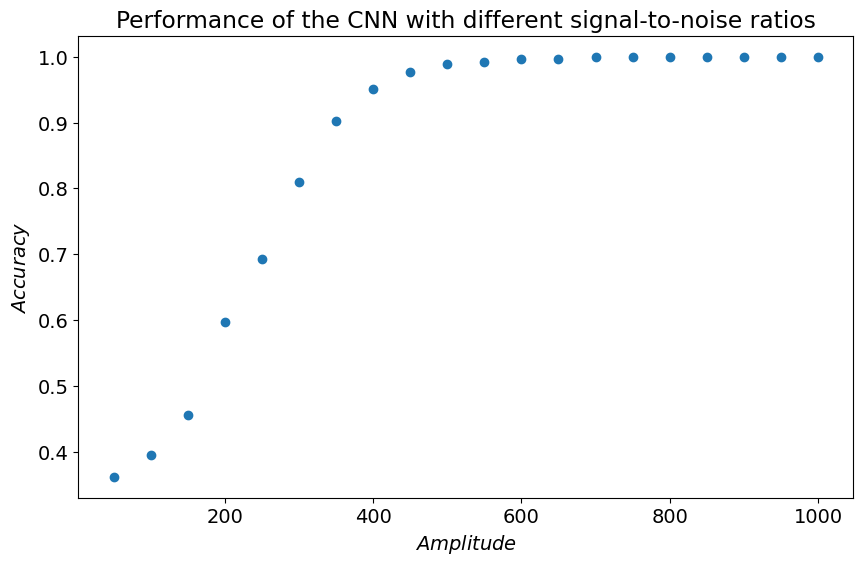

In [12]:
accuracies = []
for A in amplitudes:
    x_data, y_data = read_data(A)
    x_train, y_train, x_val, y_val = split_train_validation_rescale(x_data, y_data)
    model = create_CNN(NCONV)
    fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=0, shuffle=True)
    accuracies.append(max(fit.history['val_accuracy']))

fig, ax = plt.subplots(figsize = (10, 6))
ax.scatter(amplitudes, accuracies)
ax.set_xlabel("$Amplitude$")
ax.set_ylabel("$Accuracy$")
ax.set_title("Performance of the CNN with different signal-to-noise ratios")
fig.show()

By changing the signal-to-noise ratio - $i. e.$ the value of the amplitude $A$ - while keeping the value of $DX$ fixed, the accuracy grows with the amplitude, following an S-shaped curve. This is most likely due to the fact that for bigger values of the amplitude $A$ the signal becomes gradually more and more easily distinguishable from the noise fluctuations(whose amplitude's value remains fixed at $DX = 50$). For amplitudes higher than $A \approx 500$, the accuracy becomes $\approx 1$.

## 3. **Regularization**
### *Check if regularization may improve the performances by varying the parameter lambda (as usual in magnitude: $0, 10^{-5}, 10^{-4}, 10^{-3}, etc.$) of the L1 (LASSO) or of the L2 (Ridge) regularization; see lambda in eqs.(43) and (52) in the review. There is also a mixed version (l1_l2) that can be tried.*

In [13]:
lambdas = [float(10**(-x)) for x in range(6)]
print(lambdas)

[1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05]


In [14]:
def create_CNN_with_reg(NCONV, reg, l):
    np.random.seed(12345)
    tf_r.set_seed(12345)

    ## from keras import regularizers, initializers
    if (reg == 'l1'):
        reg = tf.keras.regularizers.l1(l)
    elif (reg == 'l2'):
        reg = tf.keras.regularizers.l2(l) ## raised to 0.2 the regularization strenghts
    elif (reg == 'l1l2'):
        reg = tf.keras.regularizers.L1L2(l1=l[0], l2=l[1])
    else:
        reg = None
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                            seed=None)
    NCONV = 1 #swtich between 1 and 2 CNNs
    NF = 5 #number of filters

    # challenge: at most 600 tunable parameters
    model = Sequential()
    # 
    if NCONV==1:
        # -----2-----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                        kernel_initializer=ini, 
                        kernel_regularizer=reg,
                        activation='relu', 
                        input_shape=input_shape))
        #model.add(MaxPooling1D(3))
        model.add(AveragePooling1D(5))
        model.add(Conv1D(filters=5, kernel_size=7, 
                        activation='relu'))
        model.add(Flatten())
        model.add(Dense(12, activation='relu'))
        model.add(Dropout(0.2))
    # 
    if NCONV==2:
        # -----1-----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                        kernel_initializer=ini, 
                        kernel_regularizer=reg, ######## TRY WITHOUT !
                        activation='relu', input_shape=input_shape))
        #model.add(MaxPooling1D(3))
        model.add(AveragePooling1D(5))
        model.add(Flatten())
        model.add(Dense(9, activation='relu'))
        model.add(Dropout(0.2)) 
        model.add(Dense(6, activation='relu'))
        model.add(Dropout(0.2))
        #model.add(Dense(10, activation='relu'))
        #model.add(Dropout(0.3))
    model.add(Dense(n_class, activation='softmax')) # softmax !

    #print('----- Model',NCONV,'-----')
    #print(model.summary())

    # optimizers
    # .SGD(lr=0.01, momentum=0.9, nesterov=True) # decay=1e-6,
    # .RMSprop()
    # .Nadam()
    opt = tf.keras.optimizers.Adam()

    # compile the model
    # categorical_crossentropy, 3 output nodes
    model.compile(loss=keras.losses.categorical_crossentropy,
                optimizer=opt,metrics=['accuracy'])
    return model

**L1: LASSO**

/tmp/ipykernel_19016/643592054.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show();


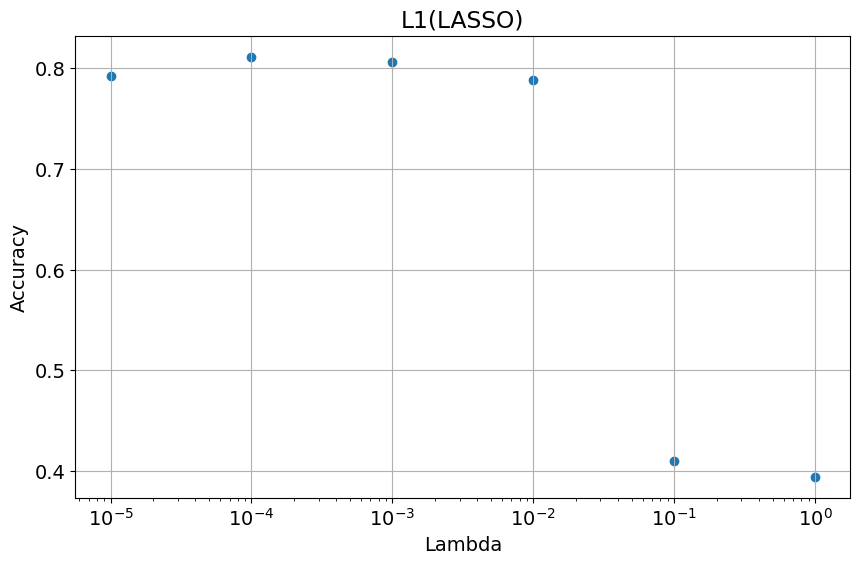

In [20]:
A = 300
x_data, y_data = read_data(A)
x_train, y_train, x_val, y_val = split_train_validation_rescale(x_data, y_data)
accuracies_L1 = []

for l in lambdas:
    model = create_CNN_with_reg(NCONV, 'l1', l)
    fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=0, shuffle=True)
    accuracies_L1.append(max(fit.history['val_accuracy']))

fig, ax = plt.subplots(figsize = (10, 6))
ax.scatter(lambdas, accuracies_L1)
ax.set_xlabel('Lambda')
ax.set_xscale('log')
ax.set_ylabel('Accuracy')
ax.set_title('L1(LASSO)')
ax.grid(True)
fig.show();

**L2: Ridge**

/tmp/ipykernel_19016/3444778075.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show();


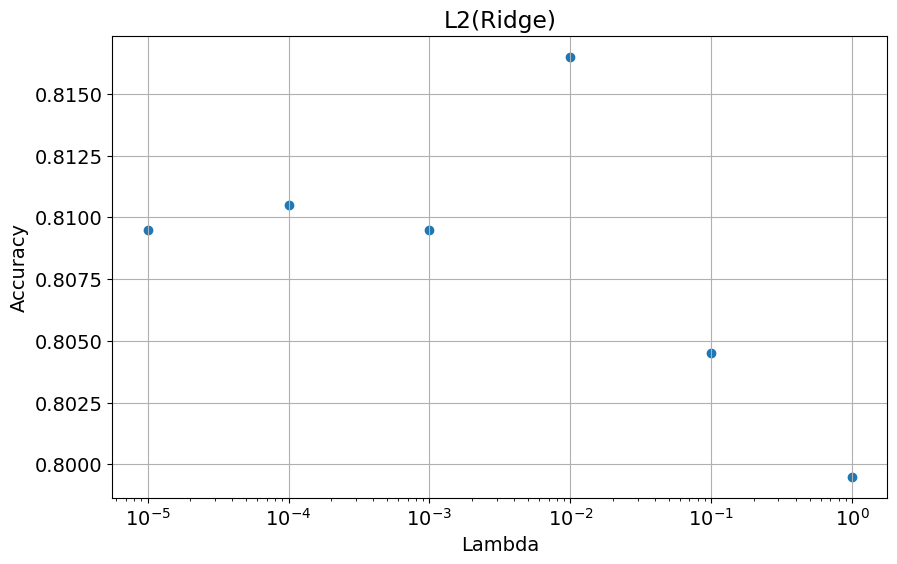

In [17]:
A = 300
x_data, y_data = read_data(A)
x_train, y_train, x_val, y_val = split_train_validation_rescale(x_data, y_data)
accuracies = []

for l in lambdas:
    model = create_CNN_with_reg(NCONV, 'l2', l)
    fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=0, shuffle=True)
    accuracies.append(max(fit.history['val_accuracy']))

fig, ax = plt.subplots(figsize = (10, 6))
ax.scatter(lambdas, accuracies)
ax.set_xlabel('Lambda')
ax.set_xscale('log')
ax.set_ylabel('Accuracy')
ax.set_title('L2(Ridge)')
ax.grid(True)
fig.show();

**L1L2**

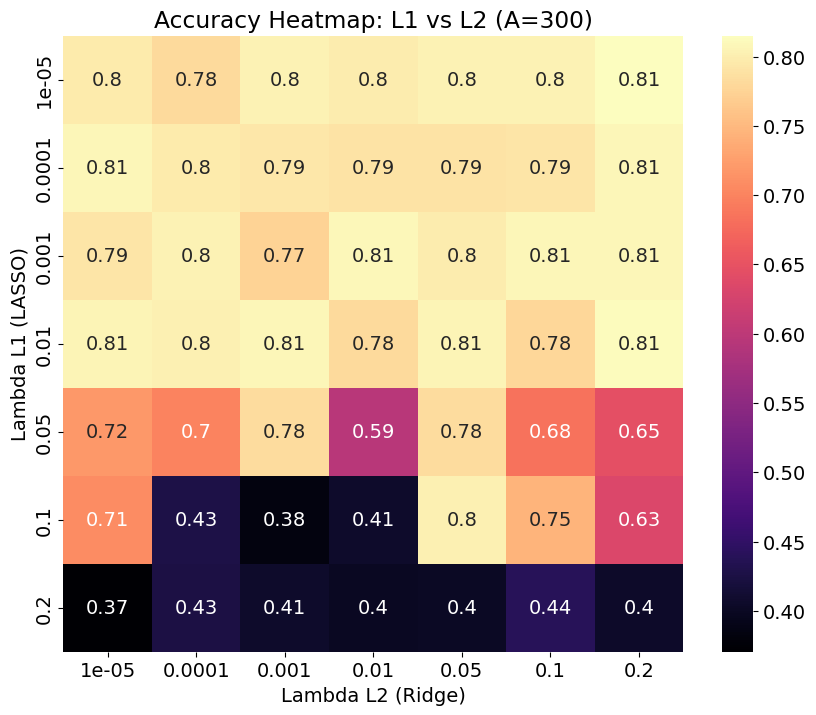

In [24]:
A = 300
x_data, y_data = read_data(A)
x_train, y_train, x_val, y_val = split_train_validation_rescale(x_data, y_data)
accuracies_matrix = []

for l1 in lambdas:
    accuracies = []
    for l2 in lambdas:
        model = create_CNN_with_reg(NCONV, 'l1l2', [l1, l2])
        fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        validation_data=(x_val, y_val),
                        verbose=0, shuffle=True)
        accuracies.append(max(fit.history['val_accuracy']))
    accuracies_matrix.append(accuracies)

labels = [f"{l}" for l in lambdas]
plt.figure(figsize=(10, 8))
sns.heatmap(accuracies_matrix,
            annot=True,
            cmap = 'magma',
            xticklabels=labels,
            yticklabels=labels
            )
plt.title(f'Accuracy Heatmap: L1 vs L2 (A={A})')
plt.xlabel('Lambda L2 (Ridge)')
plt.ylabel('Lambda L1 (LASSO)')
plt.show();

### **3.1**.
#### *Are performances of the CNN optimized at some intermediate value of lambda?*

* The **L1 LASSO regularization method** performs well for values of $\lambda$ between $10^{-5}$ and $10^{-2}$: in this range, the accuracy remains approximately constant at $\approx 0.8$. For higher values($\lambda \ge 10^{-1}$), the model reaches the underfitting region and the accuracy falls to $\approx 0.4$. **The intermediate value $\lambda \approx 10^{-2}$ is preferred**, since a stronger penalty implies a lower risk of overfitting and therefore a better generalization.
* Conversely, the **L2 Ridge regularization method** performs rather well across the range of $\lambda$. In fact, the accuracy remains stable at $\approx 0.8$, with small fluctuations around this value(with a maximum peak-to-peak range of roughly 0.014). **The best performance is at $\lambda = 10^{-2}$, as in the L1 case**.
* The performance of the **L1L2 mehod** can be understood as a combination of the performances of L1 and L2. We can clearly identify two main regions in the heatmap.
$\newline$ For $\lambda_{L1}< 10^{-1}$, the model performs well $\forall \lambda_{L2}$, with an accuracy of $\approx 0.8$(with small fluctuations).
$\newline$ For $\lambda_{L1} \ge 10^{-1}$ the CNN performs rather worse, with an accuracy of $\approx 0.4$ $\forall \lambda_{L2}$. This is a consequence of the fact that LASSO the model reaches the underfitting region in this case.
$\newline$ An exception occurs for $\lambda_{L1} = 10^{-1}$, $\lambda_{L2} = 10^{-2}$: in this case the accuracy is $0.63$.
$\newline$ Therefore, in this case, **the best performances occur when $\lambda_{L1}< 10^{-1}$**.

### **3.2**.
#### *Is there any improvement in the visualization and understanding of the weights in the filters?*

/home/federicos/miniconda3/envs/work/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


(11, 1, 5)
(5, 1, 11)


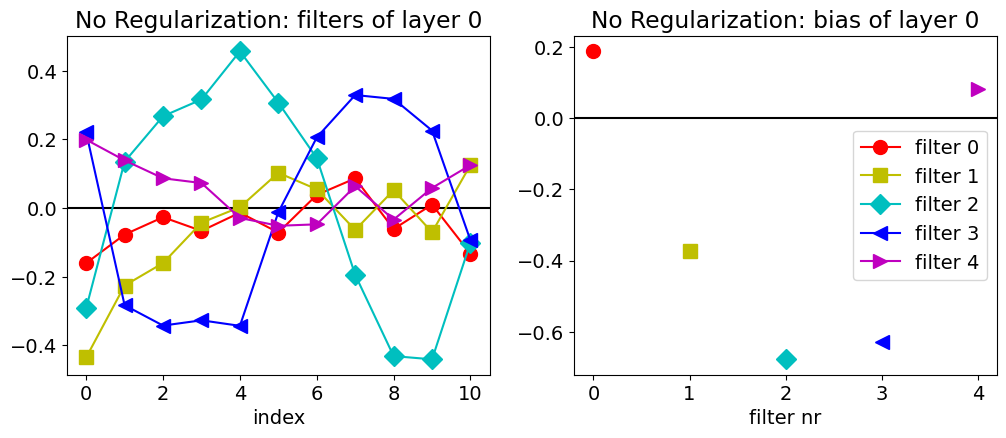

(11, 1, 5)
(5, 1, 11)


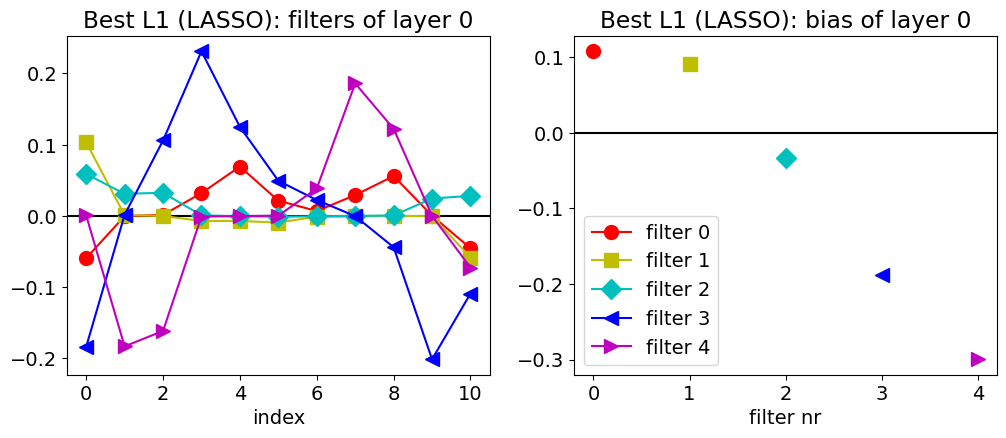

(11, 1, 5)
(5, 1, 11)


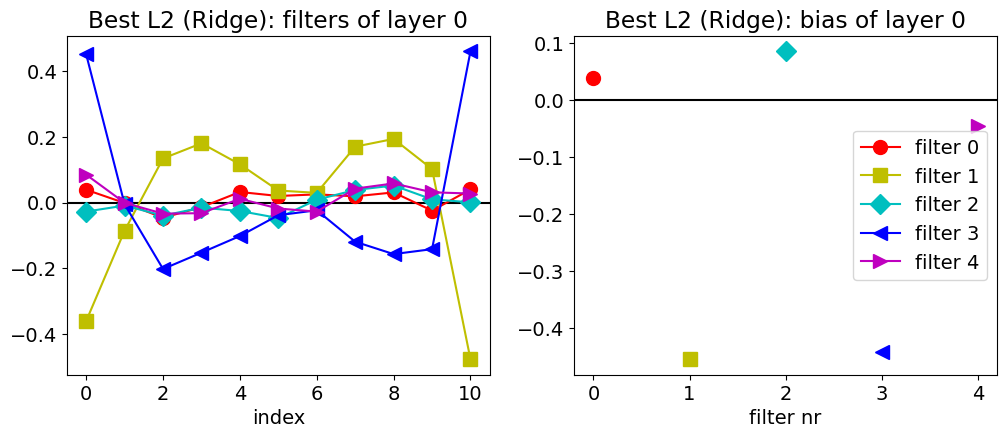

(11, 1, 5)
(5, 1, 11)


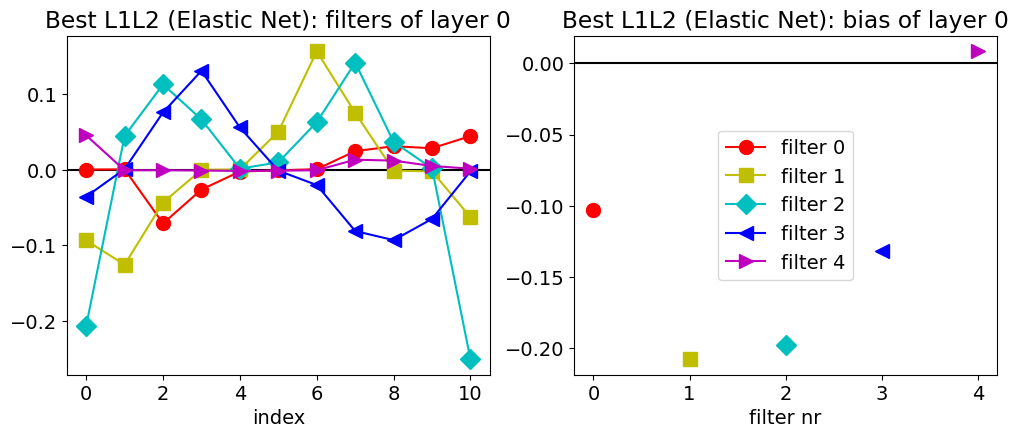

In [19]:
model_no_reg = create_CNN_with_reg(NCONV = 1, reg = None, l = 0)
fit_no_reg = model_no_reg.fit(x_train,y_train,batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        validation_data=(x_val, y_val),
                        verbose=0, shuffle=True)

best_model_L1 = create_CNN_with_reg(NCONV = 1, reg = 'l1', l = 1e-2)
fit_L1 = best_model_L1.fit(x_train,y_train,batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        validation_data=(x_val, y_val),
                        verbose=0, shuffle=True)

best_model_L2 = create_CNN_with_reg(NCONV = 1, reg = 'l2', l = 1e-2)
fit_L2 = best_model_L2.fit(x_train,y_train,batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        validation_data=(x_val, y_val),
                        verbose=0, shuffle=True)

best_model_L1L2 = create_CNN_with_reg(NCONV = 1, reg = 'l1l2', l = [1e-2, 1e-2])
fit = best_model_L1L2.fit(x_train,y_train,batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        validation_data=(x_val, y_val),
                        verbose=0, shuffle=True)

Show_weights(model_no_reg, l=0, label="No Regularization")
Show_weights(best_model_L1, l=0, label="Best L1 (LASSO)")
Show_weights(best_model_L2, l=0, label="Best L2 (Ridge)")
Show_weights(best_model_L1L2, l=0, label="Best L1L2 (Elastic Net)")

## **4. (Optional)**
*Try a CNN modeled around the best one of 2020-2021 year: three convolutional layers, no pooling, and the dense layer of the lesson replaced by a global max pooling. Is it working better? If yes, which could be the reason?*

In [21]:
def create_CNN_2021(reg, l):
    np.random.seed(12345)
    tf_r.set_seed(12345)
    if (reg == 'l1'):
        reg = tf.keras.regularizers.l1(l)
    elif (reg == 'l2'):
        reg = tf.keras.regularizers.l2(l)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                            seed=None)
    NCONV = 1 #swtich between 1 and 2 CNNs
    NF = 5 #number of filters

    model = Sequential()
    model.add(Conv1D(filters=6, kernel_size=3, 
                    kernel_initializer=ini, 
                    kernel_regularizer=reg,
                    activation='relu', 
                    input_shape=input_shape))
    model.add(Conv1D(filters=8, kernel_size=9, 
                    kernel_initializer=ini, 
                    activation='relu'))
    model.add(Conv1D(filters=4, kernel_size=3, 
                    kernel_initializer=ini, 
                    activation='relu'))
    model.add(GlobalMaxPool1D())
    model.add(Flatten())
    model.add(Dense(3, activation='softmax'))

    
    opt = tf.keras.optimizers.Adam()
    model.compile(loss=keras.losses.categorical_crossentropy,
                optimizer=opt,metrics=['accuracy'])
    return model

/home/federicos/miniconda3/envs/work/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


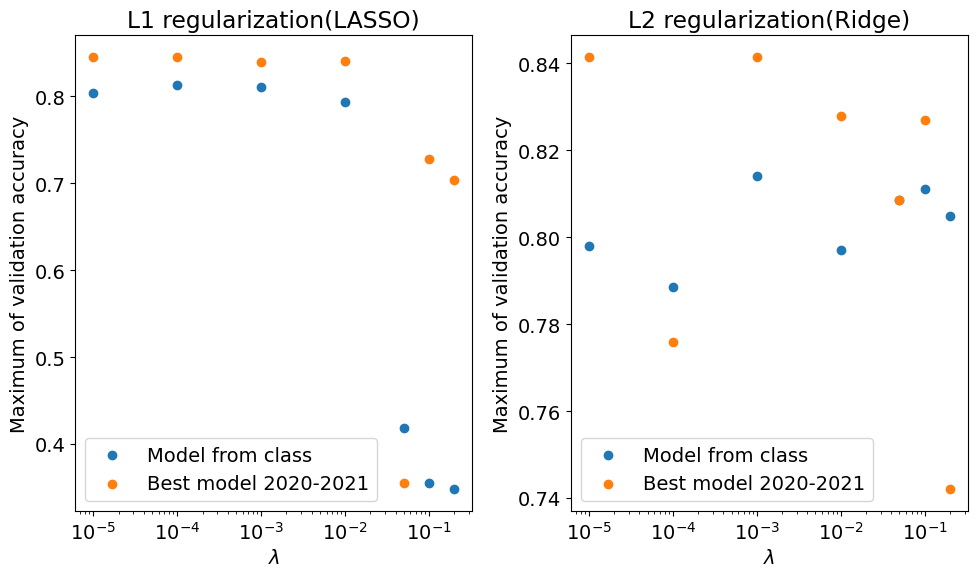

In [25]:
lambdas = [1e-5, 1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.2]
accuracies_model= {'l1': [], 'l2': []}
accuracies_model2021 = {'l1': [], 'l2': []}

NCONV = 1

for l in lambdas:
    for reg in ['l1', 'l2']:
        model = create_CNN_with_reg(NCONV, reg, l)
        fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        validation_data=(x_val, y_val),
                        verbose=0, shuffle=True)
        model_2021 = create_CNN_2021(reg, l)
        fit_2021 = model_2021.fit(x_train,y_train,batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        validation_data=(x_val, y_val),
                        verbose=0, shuffle=True)
        accuracies_model[reg].append(max(fit.history['val_accuracy']))
        accuracies_model2021[reg].append(max(fit_2021.history['val_accuracy']))
    
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 6))
ax[0].scatter(lambdas, accuracies_model['l1'], label = "Model from class")
ax[0].scatter(lambdas, accuracies_model2021['l1'], label = "Best model 2020-2021")
ax[0].set_xlabel("$\lambda$")
ax[0].set_xscale('log')
ax[0].set_ylabel("Maximum of validation accuracy")
ax[0].set_title("L1 regularization(LASSO)")
ax[0].legend()

ax[1].scatter(lambdas, accuracies_model['l2'], label = "Model from class")
ax[1].scatter(lambdas, accuracies_model2021['l2'], label = "Best model 2020-2021")
ax[1].set_xlabel("$\lambda$")
ax[1].set_xscale('log')
ax[1].set_ylabel("Maximum of validation accuracy")
ax[1].set_title("L2 regularization(Ridge)")
ax[1].legend()

plt.tight_layout()
plt.show()